# Data Exploration
### Chest X-Ray Classification: Normal vs Pneumonia vs COVID-19
This notebook explores the COVIDx-CXR dataset visualising sample images, understanding class distribution, and checking image properties before preprocessing.

In [9]:
#import libraries
import os #os interaction
import numpy as np #numerical computation
import matplotlib.pyplot as plt #visualisation
import pandas as pd #data manipulation
from PIL import Image #image loading
from pathlib import Path #handle path

In [10]:
#define dataset paths

data_dir = Path('../data/Dataset')
train_dir = data_dir/ 'Train_Validation'
test_dir = data_dir/ 'Test'

#defining class namnes
classes = ['COVID', 'Normal', 'Pneumonia']

print("Train directory: ", train_dir)
print("Test directory: ", test_dir)
print("Classes: ", classes)

Train directory:  ../data/Dataset/Train_Validation
Test directory:  ../data/Dataset/Test
Classes:  ['COVID', 'Normal', 'Pneumonia']


In [11]:
#count images in each class

print("Training set:")
for cls in classes:
    count = len(list((train_dir / cls).glob('*')))
    print(f"  {cls}: {count} images")

print("\nTest set:")
for cls in classes:
    count = len(list((test_dir / cls).glob('*')))
    print(f"  {cls}: {count} images")

Training set:
  COVID: 962 images
  Normal: 959 images
  Pneumonia: 965 images

Test set:
  COVID: 116 images
  Normal: 112 images
  Pneumonia: 113 images


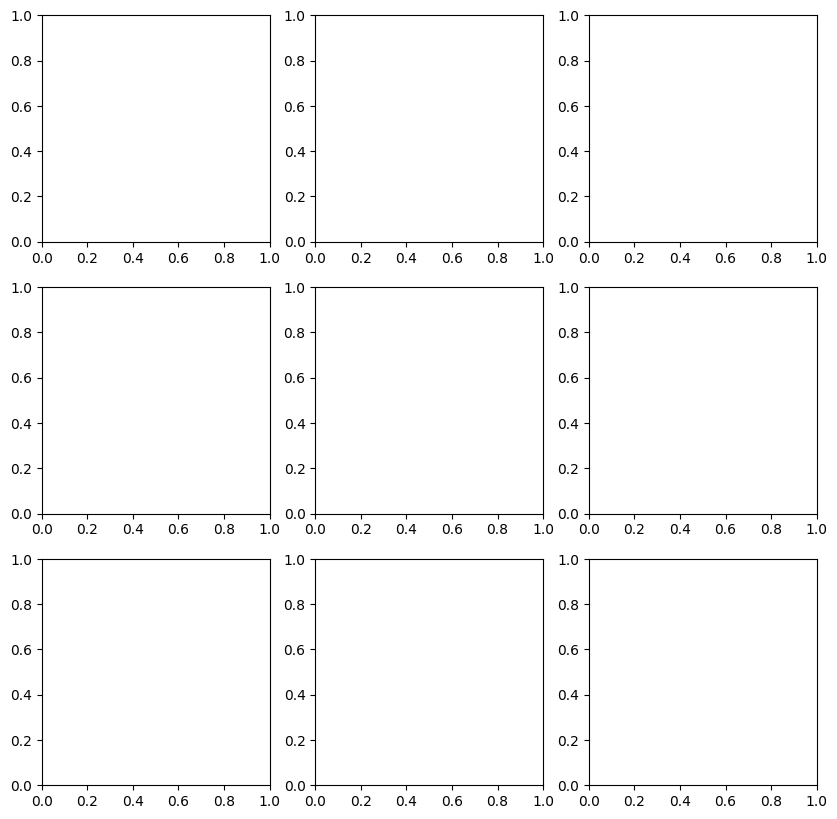

In [13]:
fig, axes = plt.subplots(3,3, figsize = (10,10))
plt.show()

In [14]:
class_dir = train_dir/ 'COVID'
images = list(class_dir.glob('*'))[:3]
print(images)

[PosixPath('../data/Dataset/Train_Validation/COVID/COVID(177).png'), PosixPath('../data/Dataset/Train_Validation/COVID/COVID(527).png'), PosixPath('../data/Dataset/Train_Validation/COVID/MIDRC-RICORD-1C-SITE2-000253-45928-0.png')]


In [15]:
img = Image.open(images[0])
print(img.size)
print(img.mode)

(256, 256)
L


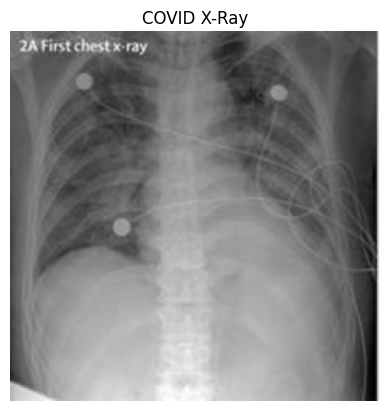

In [16]:
plt.imshow(img, cmap='gray')
plt.title('COVID X-Ray')
plt.axis('off')
plt.show()

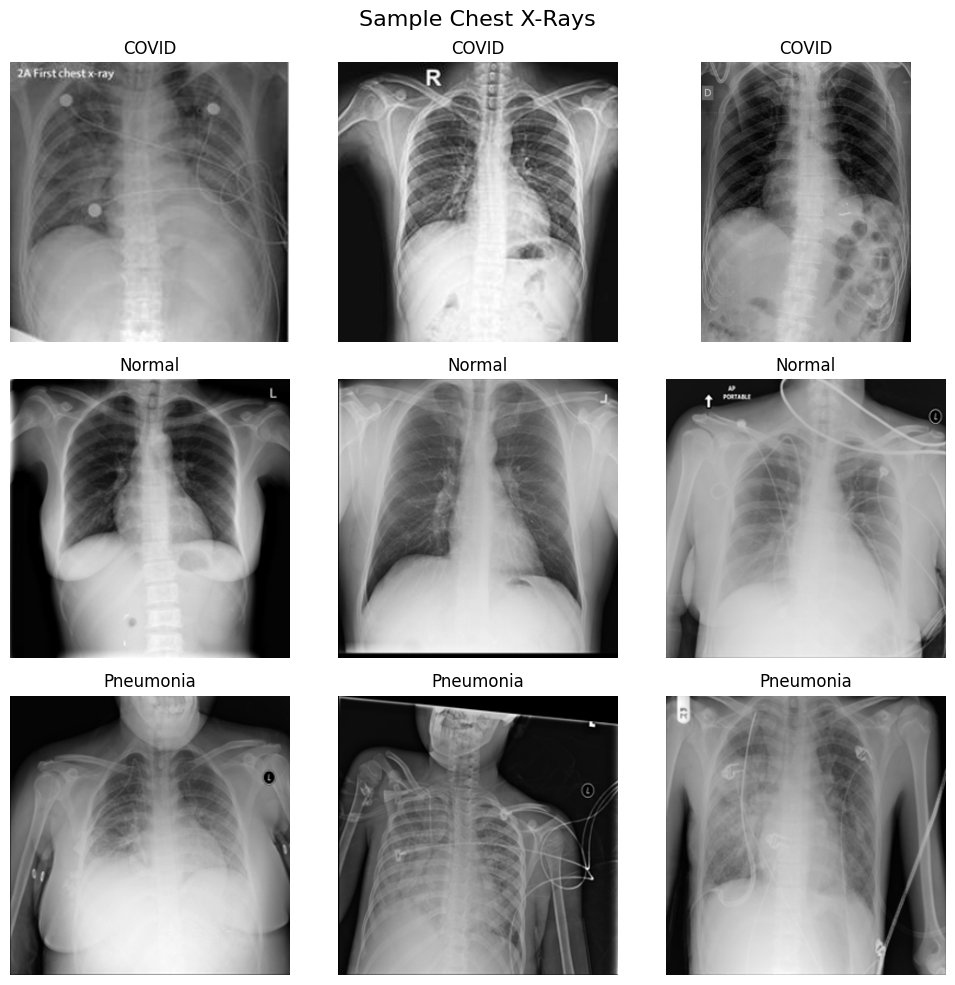

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Sample Chest X-Rays', fontsize=16)

for i, cls in enumerate(classes):
    class_dir = train_dir / cls
    images = list(class_dir.glob('*'))[:3]
    
    for j, img_path in enumerate(images):
        img = Image.open(img_path)
        axes[i][j].imshow(img, cmap='gray')
        axes[i][j].set_title(cls)
        axes[i][j].axis('off')

plt.tight_layout()
plt.show()

In [23]:
for i, cls in enumerate(classes):
    class_dir = train_dir / cls
    images = list(class_dir.glob('*'))
    
    for j, img_path in enumerate(images):
        img = Image.open(img_path)
        if(img.size!= (256,256)):
            print(img.size,img)
            print("\n")

(2779, 3707) <PIL.PngImagePlugin.PngImageFile image mode=L size=2779x3707 at 0x11EA27310>


(3480, 4240) <PIL.PngImagePlugin.PngImageFile image mode=L size=3480x4240 at 0x11EA272D0>


(3841, 3084) <PIL.PngImagePlugin.PngImageFile image mode=L size=3841x3084 at 0x11EA27310>


(299, 299) <PIL.PngImagePlugin.PngImageFile image mode=L size=299x299 at 0x11EA27610>


(299, 299) <PIL.PngImagePlugin.PngImageFile image mode=L size=299x299 at 0x11EA27310>


(2320, 2828) <PIL.PngImagePlugin.PngImageFile image mode=L size=2320x2828 at 0x11EA27610>


(299, 299) <PIL.PngImagePlugin.PngImageFile image mode=L size=299x299 at 0x11E42A510>


(299, 299) <PIL.PngImagePlugin.PngImageFile image mode=L size=299x299 at 0x11E6DFC10>


(299, 299) <PIL.PngImagePlugin.PngImageFile image mode=L size=299x299 at 0x11E3AEA10>


(4240, 3480) <PIL.PngImagePlugin.PngImageFile image mode=L size=4240x3480 at 0x11E3AEA90>


(2376, 2965) <PIL.PngImagePlugin.PngImageFile image mode=L size=2376x2965 at 0x11E8A7310>


(299, 29

## Key Findings from Data Exploration
- Dataset is balanced across three classes
- Images vary significantly in size
- Some images are RGB, most are greyscale
- Preprocessing needed: resize to 224x224, convert all to RGB, normalise